<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_11_Pandas Explode.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 🟨 Bar Plot of Top Skills for Cloud Engineers (2.11.1)

<Axes: title={'center': 'Top 10 Most Common skills for Cloud Engineers'}, xlabel='Skills', ylabel='Count'>

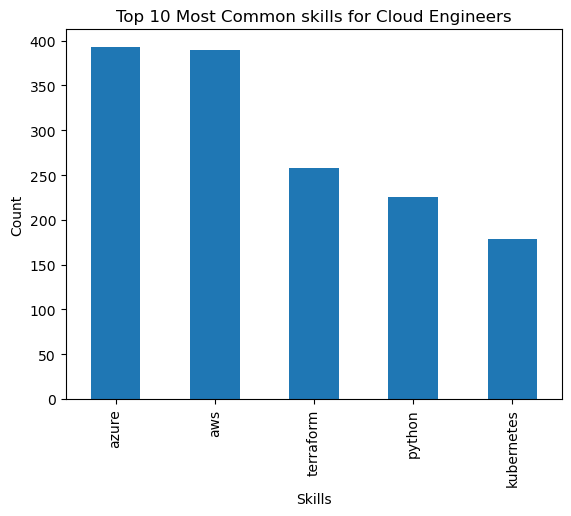

In [32]:
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_filtered = df[df['job_title'] == 'Cloud Engineer']
df_exploded = df_filtered.explode('job_skills')
df_exploded_counts = df_exploded['job_skills'].value_counts().head()
df_exploded_counts.plot(kind = 'bar', xlabel = 'Skills', ylabel = 'Count', title = 'Top 10 Most Common skills for Cloud Engineers')



---

## 🟨 Average Salary by Skill (2.11.2)

In [5]:
job_skills_exploded = df.explode('job_skills')
job_skills_avg = job_skills_exploded.groupby('job_skills')['salary_year_avg'].mean().reset_index()
job_skills_avg = job_skills_avg.sort_values(by  = 'salary_year_avg', ascending = False).head(5)
job_skills_avg





,job_skills,salary_year_avg
46,debian,196500.000000
177,ringcentral,182500.000000
114,lua,170500.000000
126,mongo,169526.929749
54,dplyr,160667.210526


---

## 🟥 Unique Skills Count (2.11.3)

In [11]:
job_skills_exploded = df.explode('job_skills')
unique_skills = job_skills_exploded.groupby('job_title_short')['job_skills'].nunique().reset_index()
unique_skills = unique_skills.rename(columns = {'job_skills':'num_unique_skills'})
unique_skills.head()

,job_title_short,num_unique_skills
0,Business Analyst,223
1,Cloud Engineer,213
2,Data Analyst,235
3,Data Engineer,239
4,Data Scientist,237


---